# real_groundtruth_multiregion.ipynb

Multi-region version of `real_groundtruth_downscale.ipynb`.

The four-scene protocol is a case study: tens of thousands of HEALPix cells,
but **four patches and one sensor**. This notebook runs the *same seven steps*
on **real Sentinel-2 patches at the 40 region anchors** already used by the
synthetic multi-region validation, so the real-data claim gets the same
statistical treatment as the synthetic one.

Note these are **Sentinel-2** acquisitions, not the Esri textures the
synthetic multi-region validation uses. They reuse only the *site list*.

**Statistical unit is the region.** One patch per region, ten regions per
scene class. The bootstrap below therefore resamples 10 independent values per
class -- a plain bootstrap over regions, not a cluster bootstrap (with a single
patch per region there is no within-region clustering left to absorb).

**Protocol** (identical to the four-scene notebook, see
`tests/real_groundtruth_common_tools.py`):

1. fetch a real, native 10 m Sentinel-2 B04 patch at the region anchor
2. PSF-aware resample the undegraded data to `NATIVE_LEVEL` (20)
3. plain no-PSF NESTED downgrade to `REF_LEVEL` (19) -- **the reference**
4. Gaussian-blur to the coarse effective resolution (FWHM 25 m)
5. point-sample every `BLOCK`-th pixel (20 m observation)
6. PSF-aware resample the coarse samples onto `REF_LEVEL`
7. compare against the reference, cell-for-cell, at `REF_LEVEL`

## Input data

The 40 patches are a **primary input**, archived like every other one:

```text
notebooks/data/multi_patch_sentinel2/region__<class>__<region_id>_data.zarr
```

They are covered by `notebooks/build_data_manifest.py`, so a normal run reads
them offline. Install the bundle with `load_data_in_zenodo.ipynb` first.

If they are not in the published archive yet, build them once with the
acquisition cell below, then rebuild the manifest and publish a new DOI.

**Prerequisite**: `tables/multi_patch_sites.csv` (written by
`multi_patch_latitude_validation.ipynb`) supplies the site list.

## Setup

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=None, marker="healpix_resample"):
    """Walk upward until a directory containing `marker` is found."""
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repo root above {p}.")


REPO_ROOT = find_repo_root()
MODULE_PATH = REPO_ROOT / "tests" / "real_groundtruth_common_tools.py"
print("module:", MODULE_PATH, "(exists:", MODULE_PATH.exists(), ")")

spec = importlib.util.spec_from_file_location("real_groundtruth_common_tools", MODULE_PATH)
gt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gt)

gt.describe_config()


module: /home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py (exists: True )
NATIVE_LEVEL=20: cell size ~= 6.22 m (reference built from real 10 m data, step 2)
REF_LEVEL=19:    cell size ~= 12.44 m (comparison level for every method, vs. 20 m coarse/degraded pixel, step 7)
DEGRADE_PSF_MODE='isotropic': FWHM_x=25.0 m, FWHM_y=25.0 m; isotropic reconstruction FWHM=25.0 m
EDGE_MARGIN_M=200 m excluded from every metric
REFERENCE_MODE='psf_aware', BASELINE_ESTIMAND='cell_average', MAX_ITER=14


## Step 0 -- register the 40 regions

One patch per region, taken at lattice position (1, 1), i.e. the region anchor
itself. The patch is chosen by **position, before any data is fetched or
scored**, so the selection cannot depend on the results.

In [2]:
scenes = gt.load_region_sites()          # patch_row=patch_col=1 by default
print(f"\n{len(scenes)} scenes registered, e.g.:")
for s in scenes[:3]:
    c = gt.region_coordinates[s]
    print(f"  {s:44s} {c['location']:22s} "
          f"lat={c['wgs84']['lat']:7.3f} lon={c['wgs84']['lon']:8.3f}")


Registered 40 regions (4 classes, {'agriculture': 10, 'forest': 10, 'urban': 10, 'water': 10}).

40 scenes registered, e.g.:
  region__urban__singapore                     Singapore              lat=  1.290 lon= 103.852
  region__urban__nairobi                       Nairobi, Kenya         lat= -1.286 lon=  36.817
  region__urban__sao_paulo                     Sao Paulo, Brazil      lat=-23.550 lon= -46.633


## Step 1 -- locate the Sentinel-2 patches

Read-only check against the frozen bundle. Nothing is downloaded here.

In [3]:
present = gt.check_region_sites()
available = present.loc[present.present, "scene"].tolist()
display(present[~present.present])
print(f"{len(available)} / {len(present)} region patches usable.")


13/40 region patches present under data/multi_patch_sentinel2.
Missing patches: install the frozen bundle (notebooks/load_data_in_zenodo.ipynb). If they are not in the archive yet, build them once with acquire_region_sites().


,scene,path,present
1,region__agriculture__canterbury,data/multi_patch_sentinel2/region__agriculture...,False
2,region__agriculture__iowa,data/multi_patch_sentinel2/region__agriculture...,False
3,region__agriculture__mato_grosso,data/multi_patch_sentinel2/region__agriculture...,False
4,region__agriculture__nile_delta,data/multi_patch_sentinel2/region__agriculture...,False
5,region__agriculture__pampas,data/multi_patch_sentinel2/region__agriculture...,False
7,region__agriculture__punjab,data/multi_patch_sentinel2/region__agriculture...,False
9,region__agriculture__western_australia,data/multi_patch_sentinel2/region__agriculture...,False
10,region__forest__amazon,data/multi_patch_sentinel2/region__forest__ama...,False
13,region__forest__borneo,data/multi_patch_sentinel2/region__forest__bor...,False
14,region__forest__canadian_rockies,data/multi_patch_sentinel2/region__forest__can...,False


13 / 40 region patches usable.


### One-off: building the bundle (skip if the archive already has it)

`acquire_region_sites()` is the only network call in this notebook and exists
to *construct* an input bundle, not to run an experiment. Run it once, then
rebuild the manifest and publish a new Zenodo version, then set `OFFLINE` back
to `True` so every later run reads archived copies.

A region with no cloud-free acquisition in `gt.REGION_DATE_WINDOW` fails here
and is skipped downstream -- a data-availability criterion, evaluated long
before any method is scored.

#### Preflight: the `eopf-zarr` backend

Acquisition reads Sentinel-2 from the EOPF STAC through
`engine="eopf-zarr"`, provided by `xarray-eopf`. That package is declared in
the **`notebooks`** pixi environment only, and `pixi.toml` warns that a PyPI
`pyproj` wheel shadowing conda's `libproj` silently *unregisters* the backend
even when the package is installed.

Both failures surface identically, as
`ValueError: unrecognized engine 'eopf-zarr'`, and only after a STAC query --
so check first rather than discovering it on region 1 of 40.

    pixi run -e notebooks jupyter lab

In [4]:
if not gt.check_eopf_engine():
    !pip install -U xarray zarr pyproj pystac-client xarray-eopf


[eopf-zarr] backend registered.


/srv/conda/envs/notebook/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [5]:
# Leave this cell unexecuted for a normal, offline run.
RUN_ACQUISITION = True

if RUN_ACQUISITION:
    gt.OFFLINE = False
    status = gt.acquire_region_sites()
    gt.OFFLINE = True
    display(status[status.status != "ok"])
    print("\nNow, from the repository root:")
    print("  python notebooks/build_data_manifest.py --doi <new DOI>")
    print("  python notebooks/build_data_manifest.py --check --doi <new DOI>")
    present = gt.check_region_sites()
    available = present.loc[present.present, "scene"].tolist()
else:
    print("Acquisition skipped; using the frozen bundle.")


/srv/conda/envs/notebook/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


[eopf-zarr] backend registered.
[region__agriculture__beauce] cached  <- S2A_MSIL2A_20260812T105651_N0512_R094_T31UCP_20260812T192512  (2026-08-12T10:56:51.024000Z, cloud 0.005677%)
[  1/40] region__agriculture__beauce: ok
[  2/40] [FAIL] region__agriculture__canterbury: RuntimeError: No items for region__agriculture__canterbury
[  3/40] [FAIL] region__agriculture__iowa: RuntimeError: No items for region__agriculture__iowa
[  4/40] [FAIL] region__agriculture__mato_grosso: RuntimeError: No items for region__agriculture__mato_grosso
[region__agriculture__nile_delta] 1 product(s) matched; using S2A_MSIL2A_20241203T083331_N0511_R021_T36RTV_20241203T114054  (2024-12-03T08:33:31.024000Z, cloud 0.005711%)
[  5/40] region__agriculture__nile_delta: ok
[  6/40] [FAIL] region__agriculture__pampas: RuntimeError: No items for region__agriculture__pampas
[region__agriculture__po_valley] cached  <- S2B_MSIL2A_20260813T101559_N0512_R065_T32TNQ_20260813T144520  (2026-08-13T10:15:59.024000Z, cloud 1.725

/srv/conda/envs/notebook/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


[  8/40] [FAIL] region__agriculture__punjab: RuntimeError: No items for region__agriculture__punjab
[region__agriculture__ukraine] cached  <- S2C_MSIL2A_20260824T085551_N0512_R007_T36UUV_20260824T122409  (2026-08-24T08:55:51.025000Z, cloud 4.50321%)
[  9/40] region__agriculture__ukraine: ok
[region__agriculture__western_australia] 1 product(s) matched; using S2A_MSIL2A_20241203T020311_N0511_R017_T50JML_20241203T045245  (2024-12-03T02:03:11.024000Z, cloud 16.90751%)
[ 10/40] region__agriculture__western_australia: ok
[ 11/40] [FAIL] region__forest__amazon: RuntimeError: No items for region__forest__amazon
[region__forest__appalachian] cached  <- S2B_MSIL2A_20250418T161829_N0511_R040_T17SKV_20250418T202014  (2025-04-18T16:18:29.024000Z, cloud 0.449474%)
[ 12/40] region__forest__appalachian: ok
[region__forest__black_forest] cached  <- S2A_MSIL2A_20260813T102701_N0512_R108_T32UMU_20260813T170810  (2026-08-13T10:27:01.024000Z, cloud 0.002143%)
[ 13/40] region__forest__black_forest: ok


/srv/conda/envs/notebook/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


[ 14/40] [FAIL] region__forest__borneo: RuntimeError: No items for region__forest__borneo
[region__forest__canadian_rockies] 2 product(s) matched; using S2A_MSIL2A_20241204T230931_N0511_R044_T60UXD_20241205T012159  (2024-12-04T23:09:31.024000Z, cloud 22.174393%)
[region__forest__canadian_rockies]   others: S2A_MSIL2A_20241204T230931_N0511_R044_T01UBU_20241205T012159
[ 15/40] region__forest__canadian_rockies: ok
[ 16/40] [FAIL] region__forest__congo: RuntimeError: No items for region__forest__congo
[region__forest__finland_boreal] cached  <- S2A_MSIL2A_20260821T095041_N0512_R079_T35VLJ_20260821T175657  (2026-08-21T09:50:41.024000Z, cloud 4.974157%)
[ 17/40] region__forest__finland_boreal: ok


/srv/conda/envs/notebook/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


[ 18/40] [FAIL] region__forest__new_zealand: RuntimeError: No items for region__forest__new_zealand
[ 19/40] [FAIL] region__forest__patagonia: RuntimeError: No items for region__forest__patagonia
[ 20/40] [FAIL] region__forest__tasmania: RuntimeError: No items for region__forest__tasmania
[ 21/40] [FAIL] region__urban__cape_town: RuntimeError: No items for region__urban__cape_town
[region__urban__mexico_city] cached  <- S2B_MSIL2A_20250420T165849_N0511_R069_T14QMG_20250420T220222  (2025-04-20T16:58:49.024000Z, cloud 0.063391%)
[ 22/40] region__urban__mexico_city: ok
[ 23/40] [FAIL] region__urban__montreal: RuntimeError: No items for region__urban__montreal
[ 24/40] [FAIL] region__urban__nairobi: RuntimeError: No items for region__urban__nairobi
[region__urban__paris] cached  <- S2A_MSIL2A_20260812T105651_N0512_R094_T31UDQ_20260812T192512  (2026-08-12T10:56:51.024000Z, cloud 0.027534%)
[ 25/40] region__urban__paris: ok
[region__urban__reykjavik] cached  <- S2A_MSIL2A_20260818T130311_N05

,scene,status,product_id,error
1,region__agriculture__canterbury,failed,,RuntimeError: No items for region__agriculture...
2,region__agriculture__iowa,failed,,RuntimeError: No items for region__agriculture...
3,region__agriculture__mato_grosso,failed,,RuntimeError: No items for region__agriculture...
5,region__agriculture__pampas,failed,,RuntimeError: No items for region__agriculture...
7,region__agriculture__punjab,failed,,RuntimeError: No items for region__agriculture...
10,region__forest__amazon,failed,,RuntimeError: No items for region__forest__amazon
13,region__forest__borneo,failed,,RuntimeError: No items for region__forest__borneo
15,region__forest__congo,failed,,RuntimeError: No items for region__forest__congo
17,region__forest__new_zealand,failed,,RuntimeError: No items for region__forest__new...
18,region__forest__patagonia,failed,,RuntimeError: No items for region__forest__pat...



Now, from the repository root:
  python notebooks/build_data_manifest.py --doi <new DOI>
  python notebooks/build_data_manifest.py --check --doi <new DOI>
16/40 region patches present under data/multi_patch_sentinel2.
Missing patches: install the frozen bundle (notebooks/load_data_in_zenodo.ipynb). If they are not in the archive yet, build them once with acquire_region_sites().


## Input-quality screen

The STAC cloud filter is a **scene-level** percentage: a granule reported at
8% cloud can still have our 2.56 km patch entirely under a cloud, and a patch
near a granule edge can be mostly no-data. Both would enter the experiment
looking perfectly legitimate.

Every criterion below reads **only the input patch** -- never a reconstruction
or a score -- and runs before any method, so screening cannot favour any
method. Rejections go to `tables/real_groundtruth_multiregion_quality.csv`.

| Criterion | Threshold | Catches |
|---|---|---|
| shape | full `CENTRAL_SIZE` | patch clipped at a granule edge |
| finite fraction | `MIN_FINITE_FRACTION` = 0.99 | no-data holes |
| relative std | `MIN_RELATIVE_STD` = 1e-3 | flat patch, degenerate reference |
| bright fraction | `MAX_BRIGHT_FRACTION` = 0.30 above 0.30 reflectance | cloud or snow over the patch |

In [ ]:
usable, quality = gt.screen_region_patches(available)
display(quality[["scene", "shape", "finite_fraction", "relative_std",
                 "bright_fraction", "usable", "flags"]])


## Steps 2-7 -- run the protocol on every region

Same code path as the four-scene notebook: `run_all()` per scene, then the
per-region rows are concatenated with their scene class and region id.

In [ ]:
metrics, failures = gt.run_multiregion(scenes=usable, force=False)

print()
print(metrics.groupby("scene_class").region_id.nunique().rename("regions").to_string())
display(failures)


## How many regions survived, and what that allows

Sentinel-2 availability, not statistics, sets the sample size here. Below
`gt.MIN_REGIONS_FOR_CI` regions a per-class bootstrap interval describes
*which sites happened to be usable*, not the class, so it is suppressed and
the class mean is reported as descriptive only.

In [ ]:
availability = gt.region_availability(metrics)
display(availability)


### Primary statistic: pooled paired comparison

Every region counts once; each competitor is paired against PSF-aware *within
the same region*, so between-site scene variability cancels. The sign test is
exact and distribution-free, which is what this sample size calls for.

**This is the number to quote in the paper.**

In [ ]:
pooled = gt.paired_summary(metrics)
display(pooled)

for _, r in pooled.iterrows():
    print(f"vs {r.competitor:20s} {int(r.psf_aware_wins):2d}/{int(r.n_regions):2d}"
          f"   sign-test p={r.sign_test_p:.3g}"
          f"   mean delta={r.mean_delta_rmse:+.5f} "
          f"[{r.delta_ci95_low:+.5f}, {r.delta_ci95_high:+.5f}]")


### The pooled result, as a figure

Left: one point per region, PSF-aware against each competitor, log-log with
the 1:1 line -- every point above the line is a region PSF-aware wins. Right:
mean paired difference with bootstrap interval, annotated with wins/n and the
exact sign test.

In [ ]:
fig = gt.plot_paired_summary(metrics, pooled)


### Secondary: per-class breakdown (descriptive where n is small)

## Region-level aggregation

Per scene class: mean RMSE per method over regions with a percentile bootstrap
interval, and the paired per-region difference against PSF-aware.

In [7]:
summary, comparisons = gt.summarize_multiregion(metrics)
display(summary)


,scene_class,method,n_regions,mean_rmse,rmse_ci95_low,rmse_ci95_high,between_region_sd
0,agriculture,classical_cubic,5,0.014045,0.012599,0.015491,NaN
1,agriculture,classical_linear,5,0.015618,0.014014,0.017223,NaN
2,agriculture,classical_nearest,5,0.015293,0.013727,0.016859,NaN
3,agriculture,psf_aware,5,0.009940,0.008869,0.011011,NaN
4,agriculture,richardson_lucy,5,0.011611,0.010156,0.013380,NaN
5,forest,classical_cubic,2,0.011150,0.005889,0.016410,0.007440
6,forest,classical_linear,2,0.012081,0.006512,0.017649,0.007875
7,forest,classical_nearest,2,0.011753,0.006372,0.017134,0.007610
8,forest,psf_aware,2,0.008221,0.004251,0.012191,0.005615
9,forest,richardson_lucy,2,0.010879,0.004999,0.016758,0.008315


In [8]:
display(comparisons[["scene_class", "competitor", "n_regions",
                     "mean_delta_rmse_competitor_minus_matched",
                     "delta_ci95_low", "delta_ci95_high",
                     "matched_win_fraction"]])

print("win fraction 1.0 everywhere:", bool((comparisons.matched_win_fraction == 1).all()))
print("every paired interval excludes zero:", bool((comparisons.delta_ci95_low > 0).all()))


,scene_class,competitor,n_regions,mean_delta_rmse_competitor_minus_matched,delta_ci95_low,delta_ci95_high,matched_win_fraction
0,agriculture,classical_cubic,4,0.004105,0.003707,0.004620,1.0
1,forest,classical_cubic,2,0.002929,0.001639,0.004219,1.0
2,urban,classical_cubic,3,0.008631,0.007222,0.009416,1.0
3,water,classical_cubic,4,0.000217,0.000060,0.000375,1.0
4,agriculture,classical_linear,4,0.005678,0.005073,0.006526,1.0
5,forest,classical_linear,2,0.003860,0.002262,0.005458,1.0
6,urban,classical_linear,3,0.011329,0.009361,0.012551,1.0
7,water,classical_linear,4,0.000298,0.000075,0.000520,1.0
8,agriculture,classical_nearest,4,0.005353,0.004742,0.006277,1.0
9,forest,classical_nearest,2,0.003532,0.002121,0.004943,1.0


win fraction 1.0 everywhere: True
every paired interval excludes zero: True


## Paper table

In [9]:
table = gt.format_multiregion_table(summary, comparisons)
display(table)


,Scene class,Regions,PSF-aware RMSE,Nearest-neighbor RMSE,Nearest-neighbor delta,Nearest-neighbor delta lo,Nearest-neighbor delta hi,Nearest-neighbor win,Bilinear RMSE,Bilinear delta,...,Bicubic RMSE,Bicubic delta,Bicubic delta lo,Bicubic delta hi,Bicubic win,Richardson-Lucy RMSE,Richardson-Lucy delta,Richardson-Lucy delta lo,Richardson-Lucy delta hi,Richardson-Lucy win
0,agriculture,5,0.009940,0.015293,0.005353,0.004742,0.006277,1.0,0.015618,0.005678,...,0.014045,0.004105,0.003707,0.004620,1.0,0.011611,0.001672,0.001251,0.002379,1.0
1,forest,2,0.008221,0.011753,0.003532,0.002121,0.004943,1.0,0.012081,0.003860,...,0.011150,0.002929,0.001639,0.004219,1.0,0.010879,0.002658,0.000748,0.004567,1.0
2,urban,3,0.032045,0.042023,0.009978,0.008229,0.011059,1.0,0.043374,0.011329,...,0.040676,0.008631,0.007222,0.009416,1.0,0.036199,0.004154,0.002888,0.005351,1.0
3,water,4,0.000996,0.001270,0.000274,0.000066,0.000481,1.0,0.001294,0.000298,...,0.001214,0.000217,0.000060,0.000375,1.0,0.001114,0.000118,0.000032,0.000204,1.0


## Figure -- per-class RMSE with bootstrap intervals

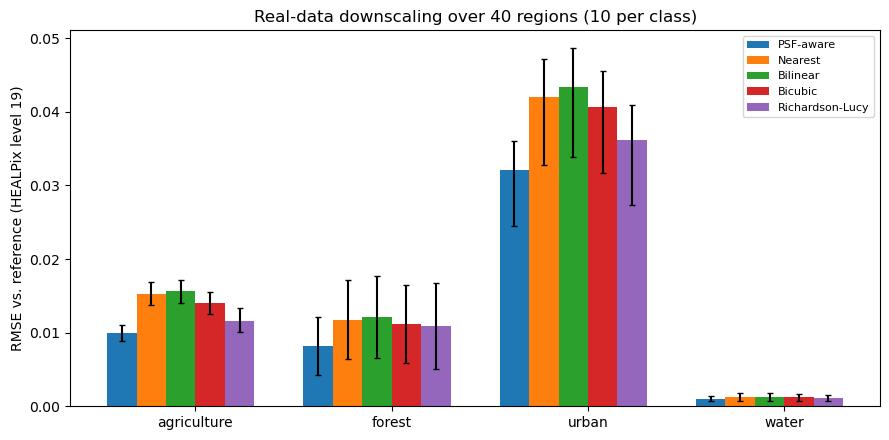

In [10]:
methods = ["psf_aware", "classical_nearest", "classical_linear",
           "classical_cubic", "richardson_lucy"]
labels = {"psf_aware": "PSF-aware", "classical_nearest": "Nearest",
          "classical_linear": "Bilinear", "classical_cubic": "Bicubic",
          "richardson_lucy": "Richardson-Lucy"}
classes = sorted(summary.scene_class.unique())

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.15
x = np.arange(len(classes))
for i, m in enumerate(methods):
    sub = summary[summary.method == m].set_index("scene_class")
    vals = [sub.loc[c, "mean_rmse"] if c in sub.index else np.nan for c in classes]
    lo = [sub.loc[c, "mean_rmse"] - sub.loc[c, "rmse_ci95_low"] if c in sub.index else 0 for c in classes]
    hi = [sub.loc[c, "rmse_ci95_high"] - sub.loc[c, "mean_rmse"] if c in sub.index else 0 for c in classes]
    ax.bar(x + (i - len(methods) / 2) * width, vals, width,
           yerr=[lo, hi], capsize=2, label=labels[m])
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel(f"RMSE vs. reference (HEALPix level {gt.REF_LEVEL})")
ax.set_title("Real-data downscaling over 40 regions (10 per class)")
ax.legend(fontsize=8)
fig.tight_layout()
gt.FIG_DIR.mkdir(exist_ok=True)
fig.savefig(gt.FIG_DIR / "real_groundtruth_multiregion_rmse.pdf", dpi=200)


## Width-mismatch control (real-data analogue of the +-50% arms)

The degradation stays at 25 m; only the **assumed** reconstruction width
changes. Note the asymmetry that makes this informative: only PSF-aware and
Richardson--Lucy use the assumed width, so a width error costs exactly the two
response-modelling methods and leaves the geometric baselines untouched.

Run on the four benchmark scenes first (cheap); pass `scenes=available` to
repeat it over all 40 regions.

In [11]:
df_wide   = gt.run_width_mismatch(scale=1.5)   # overestimated response
df_narrow = gt.run_width_mismatch(scale=0.5)   # underestimated response
df_matched = gt.run_all(force=False)

comp = (df_matched[["scene", "method", "rmse"]]
        .merge(df_wide[["scene", "method", "rmse"]], on=["scene", "method"],
               suffixes=("_matched", "_plus50"))
        .merge(df_narrow[["scene", "method", "rmse"]].rename(columns={"rmse": "rmse_minus50"}),
               on=["scene", "method"]))
comp["plus50_pct"] = 100 * (comp.rmse_plus50 - comp.rmse_matched) / comp.rmse_matched
comp["minus50_pct"] = 100 * (comp.rmse_minus50 - comp.rmse_matched) / comp.rmse_matched
display(comp)


,scene,method,rmse_matched,rmse_plus50,rmse_minus50,plus50_pct,minus50_pct
0,urban,psf_aware,0.027182,0.033994,0.034920,25.062073,2.846893e+01
1,urban,classical_nearest,0.036431,0.036264,0.036431,-0.457831,2.012047e-06
2,urban,classical_linear,0.037736,0.037610,0.037736,-0.333680,2.045964e-06
3,urban,classical_cubic,0.035285,0.035145,0.035285,-0.396636,2.254309e-06
4,urban,richardson_lucy,0.035386,0.038868,0.038949,9.839696,1.006748e+01
5,water,psf_aware,0.008972,0.009059,0.011291,0.968199,2.584451e+01
6,water,classical_nearest,0.011714,0.009467,0.011714,-19.184596,2.331894e-06
7,water,classical_linear,0.012077,0.009797,0.012077,-18.876880,2.338208e-06
8,water,classical_cubic,0.011308,0.009197,0.011308,-18.671383,2.348571e-06
9,water,richardson_lucy,0.010370,0.009411,0.011756,-9.247916,1.336225e+01


## Notes

- Every result-changing setting (`REF_LEVEL`, `BLOCK`, `RECON_FWHM_M`,
  `MAX_ITER`, `REFERENCE_MODE`, `BASELINE_ESTIMAND`, degradation mode) is
  encoded in the cache and CSV filenames via `gt._cache_suffix()`, so variants
  never overwrite each other or the four-scene result the paper's Table VI is
  built from.
- `gt.run_multiregion()` skips a region only when its patch is missing or its
  reference is degenerate. Both criteria are evaluated before any method is
  scored.
- To rerun everything from scratch, pass `force=True`; otherwise cached
  intermediate `.npz` files are reused.

## Publish the paper assets

`tex/figures/` and `tex/tables/` are separate copies of what this notebook
writes. Publishing them here keeps the compiled paper in step with the last
run instead of relying on a manual copy.

In [12]:
import sys
sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from publish_paper_assets import publish

publish()


ModuleNotFoundError: No module named 'publish_paper_assets'